# PyToch: Transfer Learning

In [24]:
import torch
import typing
from torchinfo import summary
from torch import nn
from torch import optim
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
from torchmetrics.classification import MulticlassAccuracy, MulticlassConfusionMatrix
from tqdm.auto import tqdm
from common import CV_DATASETS_DIR, plot_loss_curves

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
print(f"PyTorch: version {torch.__version__}")
print(f"PyTorch: {device.type.upper()} device")

PyTorch: version 2.11.0+cu126
PyTorch: CUDA device


In [4]:
# Hyperparameters
BATCH_SIZE = 32
#
LEARNING_RATE = 0.001

## Load Weights

In [5]:
weights = EfficientNet_V2_S_Weights.DEFAULT

## Prepare Datasets

In [6]:
DATASET_PATH = CV_DATASETS_DIR/"food"/"pizza_steak_sushi"

In [7]:
TR_DATASET_DIR = DATASET_PATH / "train"
TS_DATASET_DIR = DATASET_PATH / "test"

In [8]:
tr_dataset = datasets.ImageFolder(root=TR_DATASET_DIR, transform=weights.transforms())
ts_dataset = datasets.ImageFolder(root=TS_DATASET_DIR, transform=weights.transforms())
len(tr_dataset), len(ts_dataset)

(225, 75)

In [9]:
tr_dl = DataLoader(tr_dataset, batch_size=BATCH_SIZE, num_workers=2, shuffle=True)
ts_dl = DataLoader(ts_dataset, batch_size=BATCH_SIZE, num_workers=2, drop_last=True)
len(tr_dl), len(ts_dl)

(8, 2)

## Define Model

In [10]:
model = efficientnet_v2_s(weights=weights).to(device)

In [11]:
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280, out_features=len(tr_dataset.classes), bias=True),
).to(device)

In [12]:
# Freeze all parameters within features layers
for param in model.features.parameters():
    param.requires_grad = False

In [ ]:
summary(model=model,
        input_size=(1, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        row_settings=["var_names"])

## Train Model

In [26]:
classes = tr_dataset.classes
classes

['pizza', 'steak', 'sushi']

In [14]:
# Define loss function
criterion = nn.CrossEntropyLoss().to(device)
# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# Define metric function
accuracy = MulticlassAccuracy(num_classes=len(classes)).to(device)

In [15]:
# Define training step function
def train_step(model: nn.Module,
               loader: DataLoader,
               optimizer: optim.Optimizer,
               loss_fn: typing.Callable,
               accuracy_fn: typing.Callable,
               device: torch.device = device) -> tuple[float, float]:
    loss_avg, accu_avg = 0, 0
    model.train()
    for idx, (x, y) in enumerate(loader):
        x, y = x.to(device), y.to(device)
        y_logits = model(x)
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
        loss = loss_fn(y_logits, y)
        accu = accuracy_fn(y_pred, y)
        loss_avg += loss.item()
        accu_avg += accu.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    n_batches = len(loader)
    loss_avg /= n_batches
    accu_avg /= n_batches
    return loss_avg, accu_avg

In [16]:
# Define testing step function
def test_step(model: nn.Module,
              loader: DataLoader,
              loss_fn: typing.Callable,
              accuracy_fn: typing.Callable,
              device: torch.device = device) -> tuple[float, float]:
    loss_avg, accu_avg = 0, 0
    model.eval()
    with torch.inference_mode():
        for idx, (x, y) in enumerate(loader):
            x, y = x.to(device), y.to(device)
            y_logits = model(x)
            y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
            loss = loss_fn(y_logits, y)
            accu = accuracy_fn(y_pred, y)
            loss_avg += loss.item()
            accu_avg += accu.item()
    n_batches = len(loader)
    loss_avg /= n_batches
    accu_avg /= n_batches
    return loss_avg, accu_avg

In [17]:
N_EPOCHS = 5

tr_losses = []
ts_losses = []
tr_accus = []
ts_accus = []

for epoch in tqdm(range(N_EPOCHS)):
    # Do a train and test step
    tr_loss, tr_accu = train_step(model, tr_dl, optimizer, criterion, accuracy, device)
    ts_loss, ts_accu = test_step(model, ts_dl, criterion, accuracy, device)
    # Update history
    tr_losses.append(tr_loss)
    ts_losses.append(ts_loss)
    tr_accus.append(tr_accu)
    ts_accus.append(ts_accu)
    # Print intermediate results
    print(f"Epoch: {epoch:02} L/A: {tr_loss:.3f}/{tr_accu:3.1f} Test L/A: {ts_loss:.3f}/{ts_accu:3.1f}")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 00 L/A: 1.086/0.4 Test L/A: 0.960/0.3
Epoch: 01 L/A: 0.928/0.6 Test L/A: 0.821/0.7
Epoch: 02 L/A: 0.785/0.9 Test L/A: 0.759/0.6
Epoch: 03 L/A: 0.742/0.8 Test L/A: 0.685/0.6
Epoch: 04 L/A: 0.674/0.8 Test L/A: 0.617/0.6


## Evaluate Model

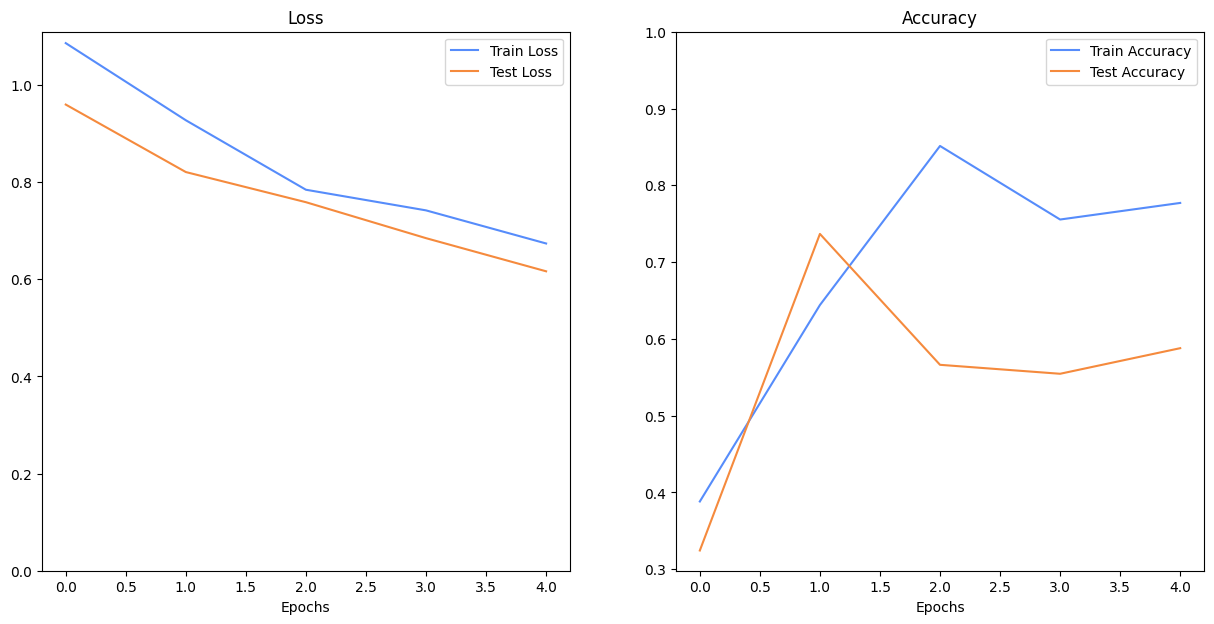

In [25]:
plot_loss_curves({
    "train_loss": tr_losses,
    "train_acc": tr_accus,
    "test_loss": ts_losses,
    "test_acc": ts_accus,
})